# Study 12 — What if improved form is temporary?

The previous studies treated genuine changes in ability as persistent. Once the player's underlying frame-win probability improved, the stronger level eventually became the new normal.

But sporting form does not always behave like that.

A player may perform at a genuinely higher level for a period and then return to their previous level. If our estimate is built from recent history, some of that stronger period will remain in memory even after the improvement itself has disappeared.

This study changes **one thing only**: the improvement is temporary.

We use a deliberately simple true-ability path:

- frames 1–1,000: frame-win probability = 58%;
- frames 1,001–1,250: frame-win probability = 64%;
- frames 1,251 onward: frame-win probability returns to 58%.

Everything else remains controlled:

- frames are independent conditional on the current true probability;
- there is no momentum;
- there is no parameter uncertainty;
- there are no opponent effects;
- the estimators are unchanged from the previous studies.

We compare:

- a 250-frame rolling window;
- an exponentially weighted estimator with `span=250` and `adjust=True`.

The question is:

> **What happens when recent good form disappears before the estimator has finished adapting to it?**

The important possibility is a two-sided lag. While the player improves, historical weaker frames may cause the estimate to understate current ability. But once the stronger period ends, those stronger frames remain in the estimator's memory and may cause it to **overstate** current ability instead.

In other words:

> **Recent form can remain embedded in an estimate after the form itself has disappeared.**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Keep the same career scale used in the previous studies so that the
# only substantive change is the temporary rather than permanent improvement.
n_frames = 1_750
baseline_p = 0.58
improved_p = 0.64

# Start with the player's baseline ability across the whole career.
true_p = np.full(n_frames, baseline_p)

# Frames 1,001–1,250 represent a temporary period of genuinely stronger play.
# Python slices are zero-indexed, so [1000:1250] corresponds to those frames.
true_p[1000:1250] = improved_p

frames = np.arange(1, n_frames + 1)

ability_path = pd.DataFrame({
    "frame": frames,
    "true_p": true_p,
})

ability_path

,frame,true_p
0,1,0.58
1,2,0.58
2,3,0.58
3,4,0.58
4,5,0.58
...,...,...
1745,1746,0.58
1746,1747,0.58
1747,1748,0.58
1748,1749,0.58


In [2]:
# Check the ability path immediately around both change points.
check_frames = [999, 1000, 1001, 1250, 1251, 1252]

ability_path.loc[
    ability_path["frame"].isin(check_frames)
]

,frame,true_p
998,999,0.58
999,1000,0.58
1000,1001,0.64
1249,1250,0.64
1250,1251,0.58
1251,1252,0.58


## Expected estimator behaviour

The true ability path now has two abrupt changes:

1. an increase from 58% to 64% at frame 1,001;
2. a return from 64% to 58% at frame 1,251.

That means the estimators should lag in **opposite directions** at the two change points.

After the improvement begins, older 58% frames remain in memory, so both estimators should initially **underestimate** the stronger current ability.

After the improvement ends, recent 64% frames remain in memory, so both estimators should temporarily **overestimate** the player's returned 58% ability.

The same memory mechanism therefore creates two different errors depending on which direction the underlying ability is moving.

We will first examine this in a noise-free setting by applying the estimators directly to the true probability path.

In [3]:
# Apply the same two estimators used in Studies 10 and 11 directly to the
# true probability path. This removes sampling noise and isolates estimator lag.
window = 250
ewm_span = 250

ability_path["rolling_250"] = (
    ability_path["true_p"]
    .rolling(window=window, min_periods=1)
    .mean()
)

ability_path["ewm_250"] = (
    ability_path["true_p"]
    .ewm(span=ewm_span, adjust=True)
    .mean()
)

check_frames = [1000, 1001, 1050, 1100, 1200, 1250, 1251, 1300, 1350, 1400, 1500]

ability_path.loc[
    ability_path["frame"].isin(check_frames),
    ["frame", "true_p", "rolling_250", "ewm_250"]
]

,frame,true_p,rolling_250,ewm_250
999,1000,0.58,0.58000,0.580000
1000,1001,0.64,0.58024,0.580478
1049,1050,0.64,0.59200,0.599785
1099,1100,0.64,0.60400,0.613045
1199,1200,0.64,0.62800,0.627890
1249,1250,0.64,0.64000,0.631882
1250,1251,0.58,0.63976,0.631469
1299,1300,0.58,0.62800,0.614777
1349,1350,0.58,0.61600,0.603312
1399,1400,0.58,0.60400,0.595626


## The stronger period remains in memory

The noise-free paths show the expected two-sided lag.

When ability rises to 64%, both estimators initially remain below the player's current level because they still contain evidence from the earlier 58% period.

There is an important detail in this particular design. The stronger spell lasts exactly 250 frames, the same length as the rolling window. As a result, the rolling estimator has just enough time to reach the full 64% level at frame 1,250. The exponentially weighted estimator still retains some older history and reaches only about 63.19%.

But the underlying ability then immediately returns to 58%.

At frame 1,251:

- true ability = 58%;
- rolling 250 estimate = 63.98%;
- EWM 250 estimate = 63.15%.

Both estimators therefore switch from **underestimating** the stronger player to **overestimating** the returned baseline player.

Nothing has gone wrong with either estimator. They are simply remembering evidence generated under a level of ability that is no longer current.

In [4]:
# After the stronger period ends, estimator lag changes sign:
# remembered strong frames now make current ability look too high.
ability_path["rolling_error"] = (
    ability_path["rolling_250"] - ability_path["true_p"]
)

ability_path["ewm_error"] = (
    ability_path["ewm_250"] - ability_path["true_p"]
)

post_form_frames = [1251, 1300, 1350, 1400, 1450, 1500, 1600, 1750]

post_form_errors = ability_path.loc[
    ability_path["frame"].isin(post_form_frames),
    ["frame", "true_p", "rolling_250", "ewm_250",
     "rolling_error", "ewm_error"]
].copy()

# Express the errors as percentage points for easier interpretation.
post_form_errors["rolling_error_pp"] = post_form_errors["rolling_error"] * 100
post_form_errors["ewm_error_pp"] = post_form_errors["ewm_error"] * 100

post_form_errors[
    ["frame", "rolling_error_pp", "ewm_error_pp"]
]

,frame,rolling_error_pp,ewm_error_pp
1250,1251,5.976,5.146890
1299,1300,4.800,3.477717
1349,1350,3.600,2.331155
1399,1400,2.400,1.562606
1449,1450,1.200,1.047439
1499,1500,0.000,0.702116
1599,1600,0.000,0.315479
1749,1750,0.000,0.095020


In [5]:
# Compare the size of the post-form errors to find when the rolling
# estimator becomes closer to current ability than the EWM.
post_form = ability_path.loc[
    ability_path["frame"] >= 1251
].copy()

post_form["rolling_abs_error"] = post_form["rolling_error"].abs()
post_form["ewm_abs_error"] = post_form["ewm_error"].abs()

post_form["rolling_closer"] = (
    post_form["rolling_abs_error"] <= post_form["ewm_abs_error"]
)

crossover_row = post_form.loc[
    post_form["rolling_closer"]
].iloc[0]

crossover_row[
    ["frame", "true_p", "rolling_250", "ewm_250",
     "rolling_abs_error", "ewm_abs_error"]
]

frame                    1460
true_p                   0.58
rolling_250            0.5896
ewm_250              0.589669
rolling_abs_error      0.0096
ewm_abs_error        0.009669
Name: 1459, dtype: object

## The advantage eventually reverses

Immediately after the stronger period ends, the exponentially weighted estimator is closer to the player's returned 58% ability.

That happens because exponential weighting reduces the influence of the old 64% frames continuously, whereas the rolling window still contains many of them at full weight.

But the rolling window has a different advantage: once a strong frame becomes more than 250 frames old, it disappears completely.

The crossover occurs at frame 1,460, 210 frames after the stronger spell ended.

At that point:

- true ability = 58.00%;
- rolling 250 estimate = 58.96%;
- EWM 250 estimate = 58.97%.

Before frame 1,460, the EWM is closer to current ability.

From frame 1,460 onward, the rolling estimator is closer.

This is the same basic memory trade-off seen earlier, but now applied to temporary form:

> **Exponential weighting forgets vanished form sooner at first, while a hard rolling cutoff eventually removes it completely.**

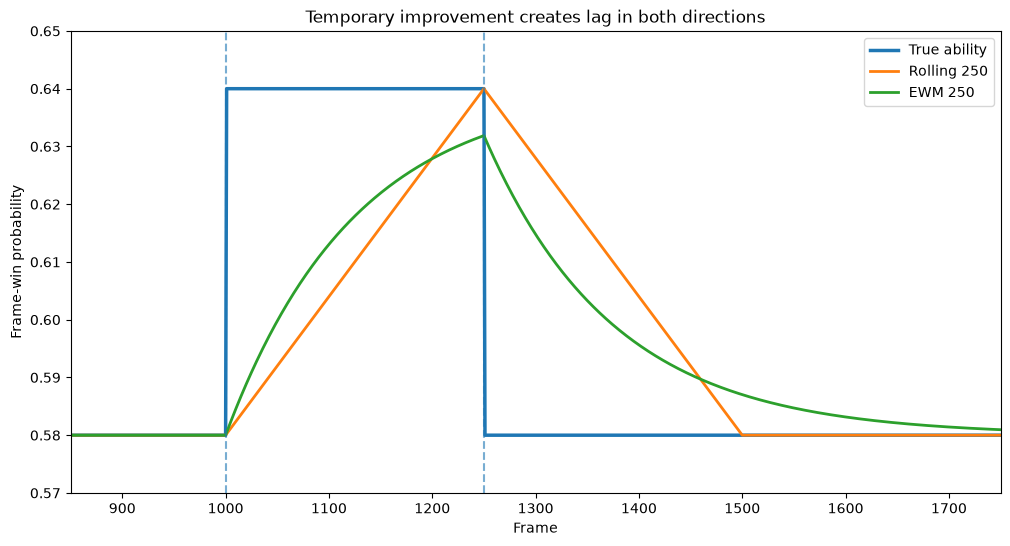

In [6]:
# Plot the true ability path against both estimators so the two-sided lag
# is visible across the temporary improvement and the return to baseline.
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    ability_path["frame"],
    ability_path["true_p"],
    label="True ability",
    linewidth=2.5,
)

ax.plot(
    ability_path["frame"],
    ability_path["rolling_250"],
    label="Rolling 250",
    linewidth=2,
)

ax.plot(
    ability_path["frame"],
    ability_path["ewm_250"],
    label="EWM 250",
    linewidth=2,
)

ax.axvline(1000, linestyle="--", alpha=0.6)
ax.axvline(1250, linestyle="--", alpha=0.6)

ax.set_title("Temporary improvement creates lag in both directions")
ax.set_xlabel("Frame")
ax.set_ylabel("Frame-win probability")
ax.set_xlim(850, 1750)
ax.set_ylim(0.57, 0.65)
ax.legend()

plt.show()

## A temporary change creates two-sided tracking error

The noise-free paths make the effect of temporary form visible.

When true ability jumps from 58% to 64%, both estimators initially lag below the new level. Their histories still contain weaker frames from before the improvement.

When true ability returns to 58%, the direction of the error reverses. The estimators now remain above current ability because their histories contain frames generated during the stronger period.

The exponentially weighted estimator responds more quickly in both directions. It rises faster when form improves and falls faster when that form disappears.

The rolling estimator responds more slowly at first, but its fixed memory gives it a different long-run behaviour. Once every 64% frame has left the 250-frame window, the temporary improvement disappears from the estimate completely.

The EWM has no equivalent hard cutoff. The influence of the stronger period becomes progressively smaller but remains present for longer.

This gives temporary form a useful interpretation:

> **An estimate can continue to reflect a period of good form after the underlying form itself has already disappeared.**

The resulting error is not evidence that the estimator is malfunctioning. It is the predictable consequence of using historical evidence to track an ability level that has changed again.

In [7]:
# Simulate many independent careers using the temporary true-ability path.
# Work in batches so we do not need to keep all 10,000 careers in memory.
n_simulations = 10_000
batch_size = 1_000
rng = np.random.default_rng(2026)

rolling_mean_sum = np.zeros(n_frames)
ewm_mean_sum = np.zeros(n_frames)

rolling_denominator = np.minimum(
    np.arange(1, n_frames + 1),
    window,
)

alpha = 2 / (ewm_span + 1)
decay = 1 - alpha

for start in range(0, n_simulations, batch_size):
    batch_n = min(batch_size, n_simulations - start)

    # Each frame is won independently using the true probability at that frame.
    outcomes = (
        rng.random((batch_n, n_frames)) < true_p
    ).astype(np.int8)

    # Rolling 250 estimates for every career in the batch.
    cumulative = np.cumsum(outcomes, axis=1, dtype=np.int32)
    rolling_sums = cumulative.astype(float)
    rolling_sums[:, window:] -= cumulative[:, :-window]

    rolling_estimates = (
        rolling_sums / rolling_denominator
    )

    rolling_mean_sum += rolling_estimates.sum(axis=0)

    # Reproduce pandas EWM with adjust=True using its weighted-average
    # recurrence, while keeping only the current estimate in memory.
    weighted_sum = outcomes[:, 0].astype(float)
    weight_sum = 1.0

    ewm_mean_sum[0] += (weighted_sum / weight_sum).sum()

    for frame_idx in range(1, n_frames):
        weighted_sum = (
            outcomes[:, frame_idx]
            + decay * weighted_sum
        )
        weight_sum = 1 + decay * weight_sum

        ewm_mean_sum[frame_idx] += (
            weighted_sum / weight_sum
        ).sum()

ability_path["sim_mean_rolling_250"] = (
    rolling_mean_sum / n_simulations
)

ability_path["sim_mean_ewm_250"] = (
    ewm_mean_sum / n_simulations
)

simulation_check_frames = [
    1000, 1001, 1100, 1250,
    1251, 1300, 1400, 1500, 1750
]

ability_path.loc[
    ability_path["frame"].isin(simulation_check_frames),
    [
        "frame",
        "true_p",
        "rolling_250",
        "sim_mean_rolling_250",
        "ewm_250",
        "sim_mean_ewm_250",
    ],
]

,frame,true_p,rolling_250,sim_mean_rolling_250,ewm_250,sim_mean_ewm_250
999,1000,0.58,0.58000,0.580460,0.580000,0.580415
1000,1001,0.64,0.58024,0.580692,0.580478,0.580858
1099,1100,0.64,0.60400,0.604242,0.613045,0.613115
1249,1250,0.64,0.64000,0.639908,0.631882,0.631982
1250,1251,0.58,0.63976,0.639680,0.631469,0.631557
1299,1300,0.58,0.62800,0.627972,0.614777,0.614834
1399,1400,0.58,0.60400,0.603947,0.595626,0.595465
1499,1500,0.58,0.58000,0.579387,0.587021,0.586244
1749,1750,0.58,0.58000,0.579902,0.580950,0.580866


In [8]:
# Measure how closely the repeated-career mean paths reproduce the exact
# noise-free estimator paths across the whole simulated career.
ability_path["rolling_sim_difference"] = (
    ability_path["sim_mean_rolling_250"]
    - ability_path["rolling_250"]
)

ability_path["ewm_sim_difference"] = (
    ability_path["sim_mean_ewm_250"]
    - ability_path["ewm_250"]
)

max_rolling_difference_pp = (
    ability_path["rolling_sim_difference"].abs().max() * 100
)

max_ewm_difference_pp = (
    ability_path["ewm_sim_difference"].abs().max() * 100
)

print(
    f"Maximum rolling mean deviation: "
    f"{max_rolling_difference_pp:.3f} percentage points"
)

print(
    f"Maximum EWM mean deviation: "
    f"{max_ewm_difference_pp:.3f} percentage points"
)

Maximum rolling mean deviation: 1.010 percentage points
Maximum EWM mean deviation: 1.010 percentage points


In [9]:
# Locate the largest simulation-versus-expectation differences rather than
# summarising the whole career with a maximum that may occur during startup.
rolling_max_idx = ability_path["rolling_sim_difference"].abs().idxmax()
ewm_max_idx = ability_path["ewm_sim_difference"].abs().idxmax()

print("Largest rolling deviation:")
print(
    ability_path.loc[
        rolling_max_idx,
        ["frame", "rolling_250", "sim_mean_rolling_250",
         "rolling_sim_difference"]
    ]
)

print("\nLargest EWM deviation:")
print(
    ability_path.loc[
        ewm_max_idx,
        ["frame", "ewm_250", "sim_mean_ewm_250",
         "ewm_sim_difference"]
    ]
)

# Also measure agreement over the part of the career relevant to this study,
# where both estimators already have substantial history.
study_period = ability_path.loc[
    ability_path["frame"] >= 1000
]

print(
    "\nMaximum rolling deviation from frame 1,000 onward: "
    f"{study_period['rolling_sim_difference'].abs().max() * 100:.3f} pp"
)

print(
    "Maximum EWM deviation from frame 1,000 onward: "
    f"{study_period['ewm_sim_difference'].abs().max() * 100:.3f} pp"
)

Largest rolling deviation:
frame                     1.0000
rolling_250               0.5800
sim_mean_rolling_250      0.5901
rolling_sim_difference    0.0101
Name: 0, dtype: float64

Largest EWM deviation:
frame                 1.0000
ewm_250               0.5800
sim_mean_ewm_250      0.5901
ewm_sim_difference    0.0101
Name: 0, dtype: float64

Maximum rolling deviation from frame 1,000 onward: 0.094 pp
Maximum EWM deviation from frame 1,000 onward: 0.090 pp


## Repeated careers confirm the systematic pattern

The same temporary ability path was simulated across 10,000 independent careers.

The repeated-career mean estimates closely reproduce the exact noise-free paths around both changes in ability.

For example:

- at frame 1,250, expected rolling = 64.00% and simulated mean rolling = 63.99%;
- at frame 1,250, expected EWM = 63.19% and simulated mean EWM = 63.20%;
- at frame 1,300, expected rolling = 62.80% and simulated mean rolling = 62.80%;
- at frame 1,300, expected EWM = 61.48% and simulated mean EWM = 61.48%;
- at frame 1,500, expected rolling = 58.00% and simulated mean rolling = 57.94%;
- at frame 1,500, expected EWM = 58.70% and simulated mean EWM = 58.62%.

From frame 1,000 onward, the maximum difference between the simulated mean and exact expected path was only:

- **0.094 percentage points** for the rolling estimator;
- **0.090 percentage points** for the exponentially weighted estimator.

The much larger whole-career maximum occurred at frame 1, when every simulated estimate is based on a single binary outcome and therefore has unusually high sampling variability.

The close agreement over the period relevant to this study confirms that the two-sided lag is not a peculiarity of one simulated career.

> **The tendency to underestimate newly improved form and then overestimate ability after that form disappears is a systematic consequence of estimator memory.**

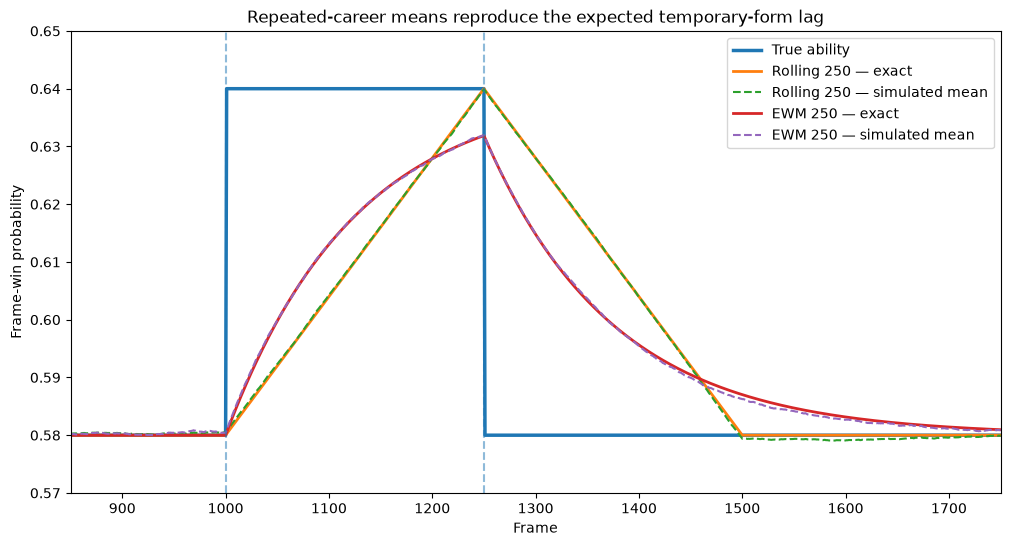

In [10]:
# Overlay the simulated mean paths on the exact expected paths.
# If the simulation is behaving as expected, each pair should almost coincide.
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    ability_path["frame"],
    ability_path["true_p"],
    label="True ability",
    linewidth=2.5,
)

ax.plot(
    ability_path["frame"],
    ability_path["rolling_250"],
    label="Rolling 250 — exact",
    linewidth=2,
)

ax.plot(
    ability_path["frame"],
    ability_path["sim_mean_rolling_250"],
    label="Rolling 250 — simulated mean",
    linestyle="--",
    linewidth=1.5,
)

ax.plot(
    ability_path["frame"],
    ability_path["ewm_250"],
    label="EWM 250 — exact",
    linewidth=2,
)

ax.plot(
    ability_path["frame"],
    ability_path["sim_mean_ewm_250"],
    label="EWM 250 — simulated mean",
    linestyle="--",
    linewidth=1.5,
)

ax.axvline(1000, linestyle="--", alpha=0.5)
ax.axvline(1250, linestyle="--", alpha=0.5)

ax.set_title("Repeated-career means reproduce the expected temporary-form lag")
ax.set_xlabel("Frame")
ax.set_ylabel("Frame-win probability")
ax.set_xlim(850, 1750)
ax.set_ylim(0.57, 0.65)
ax.legend()

plt.show()

## Conclusion

This study changed one feature of the previous model: the improvement in ability was temporary rather than permanent.

The player's true frame-win probability followed a deliberately simple path:

- 58% through frame 1,000;
- 64% for frames 1,001–1,250;
- back to 58% from frame 1,251 onward.

This creates lag in both directions.

When the stronger period begins, both estimators initially **underestimate** current ability because their memories still contain weaker 58% frames.

When the stronger period ends, the same mechanism reverses. Frames generated at the temporary 64% level remain in memory, causing both estimators to **overestimate** current ability after the player has already returned to 58%.

Immediately after the return to baseline at frame 1,251:

- true ability = 58.00%;
- rolling 250 estimate = 63.98%;
- EWM 250 estimate = 63.15%.

The exponentially weighted estimator initially sheds the vanished form more quickly because recent weaker observations receive greater weight.

The rolling estimator eventually catches up because its memory has a hard boundary. The exact crossover occurs at frame 1,460, 210 frames after the stronger period ended:

- rolling estimate = 58.96%;
- EWM estimate = 58.97%.

By frame 1,500, every 64% frame has left the rolling window, so its expected estimate has returned exactly to 58%. The EWM still retains a diminishing trace of the stronger period.

Simulation of 10,000 independent careers reproduced these expected paths closely. From frame 1,000 onward, the maximum difference between the repeated-career mean and the exact expected path was only 0.094 percentage points for the rolling estimator and 0.090 percentage points for the EWM.

The central result is:

> **Recent form can remain embedded in an estimate after the form itself has disappeared.**

More generally:

> **Estimator memory does not know why recent performance was strong. It continues to carry that evidence until its weighting scheme removes it.**

This extends the tracking problem from Study 11. When ability can both rise and fall, lag is not merely a delay in recognising improvement. The same historical memory can later make a player look stronger than they currently are.

### What this study does not show

This deliberately controlled example does not attempt to determine whether real changes in observed performance represent:

- genuine changes in underlying ability;
- temporary form;
- opponent strength;
- match conditions;
- momentum;
- ordinary random variation.

The 250-frame stronger period is illustrative rather than estimated from real data, and neither estimator has been optimised.

Those questions require a different problem:

> **Can we distinguish genuine changes in ability from ordinary random variation?**

## Study 12 summary

Study 12 asked:

> **What happens when recent good form disappears before the estimator has finished adapting to it?**

Controlled true-ability path:

- frames 1–1,000: 58%;
- frames 1,001–1,250: 64%;
- frames 1,251–1,750: 58%.

Compared estimators:

- rolling window = 250 frames;
- EWM = `span=250`, `adjust=True`.

Key noise-free results:

| Frame | True p | Rolling 250 | EWM 250 |
|---:|---:|---:|---:|
| 1,000 | 58.00% | 58.00% | 58.00% |
| 1,250 | 64.00% | 64.00% | 63.19% |
| 1,251 | 58.00% | 63.98% | 63.15% |
| 1,300 | 58.00% | 62.80% | 61.48% |
| 1,400 | 58.00% | 60.40% | 59.56% |
| 1,460 | 58.00% | 58.96% | 58.97% |
| 1,500 | 58.00% | 58.00% | 58.70% |
| 1,750 | 58.00% | 58.00% | 58.10% |

Post-form crossover:

- exact crossover frame: **1,460**;
- 210 frames after the temporary stronger period ended.

Repeated-career validation:

- 10,000 independent careers;
- maximum rolling mean deviation from frame 1,000 onward: **0.094 pp**;
- maximum EWM mean deviation from frame 1,000 onward: **0.090 pp**.

Central conclusion:

> **Recent form can remain embedded in an estimate after the form itself has disappeared.**

Story progression:

- Study 07: keeping all history can make an estimate stale;
- Study 08: forgetting history improves responsiveness but sacrifices stability;
- Study 09: memory length controls that trade-off;
- Study 10: the way history is forgotten matters;
- Study 11: moving ability turns estimation into a tracking problem;
- Study 12: temporary form can remain in the estimate after the form itself is gone.

Natural next question:

> **Can we distinguish genuine ability change from ordinary random variation?**